In [1]:
# useful to autoreload the module without restarting the kernel
%load_ext autoreload
%autoreload 2

In [2]:
from mppi import Parsers as P
from mppi.Utilities import LRoptics as LR, Utils as U
import matplotlib.pyplot as plt
from mppi.Utilities import Constants as C
from mppi.Utilities import FourierTransform as FT
import numpy as np
import os

# Analysis of the Optics modules

This notebook describes the various modules of the package built in order to extract both the linear and non-linear optical properties of a system
from the knowledge of the real-time polarization.

## Linear response analysis

We show how to compute the linear response starting from the real-time polarization.

To this aim we load the ndb produced by yambo_nl for LiF in the linear response regime

In [5]:
file = 'YamboParser_test/nl_results/LiF-delta_pulse/ndb.Nonlinear'

In [6]:
data = P.YamboNLDBParser(file)

Parse file : YamboParser_test/nl_results/LiF-delta_pulse/ndb.Nonlinear
Field 2 not found
Field 3 not found


In [7]:
time_fs = data.get_time() # in fs
time_au = data.IO_TIME_points
P_t = data.Polarization[0]
efield = data.Efield[0]
t_initial_au=efield["initial_time"]
t_initial_fs = t_initial_au/C.FsToAu

The module can deal with both time variables expressed in fs or in au.

The damp_ft function applies a damping in the time domain to produce a spread in the frequency domain and avoid 
spurious oscillations of the optical quantities.
The damping eta is expressed in eV

In [8]:
P_damped = U.damp_ft(P_t,time_fs,t_initial=t_initial_fs,eta=0.1,time_units='fs')

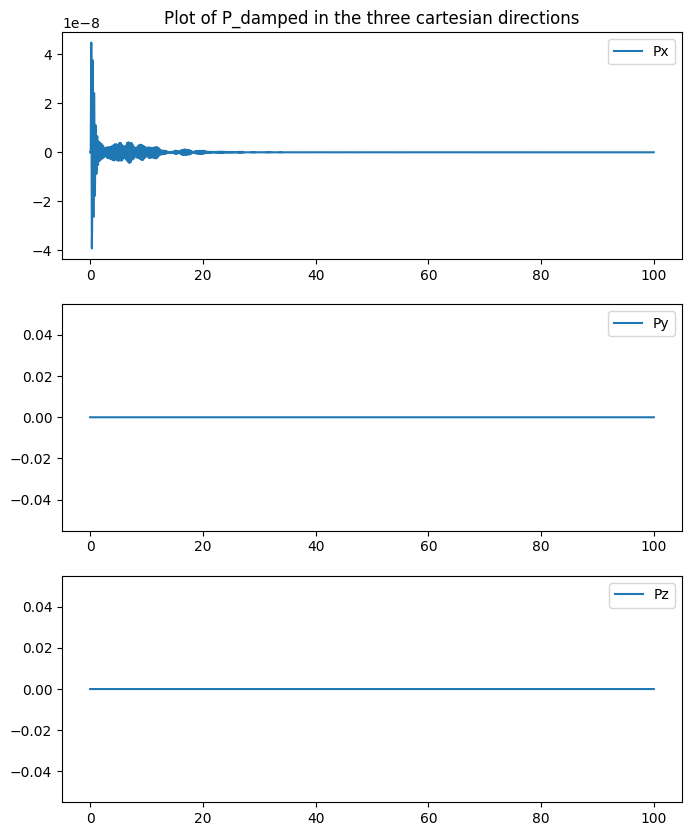

In [9]:
U.Plot_3dArray(time_fs,P_damped,label='P_damped')

The linear response is computed by the Linear_response function of the module

In [10]:
energy,chi = LR.Linear_Response(time_fs,P_t,efield=efield,eta=0.1,time_units='fs')

Time units = fs. Rescaled to au


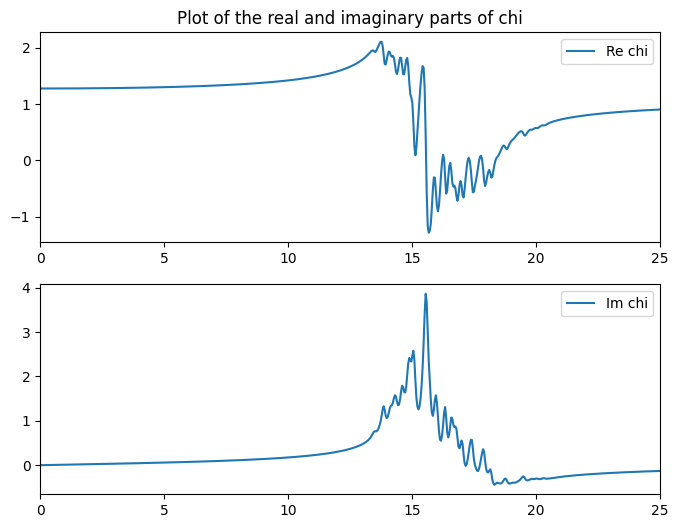

In [11]:
U.Plot_ComplexArray(energy,chi,xlim=(0,25),label='chi')

In [23]:
np.power?

Signature:       np.power(*args, **kwargs)
Type:            ufunc
String form:     <ufunc 'power'>
File:            c:\users\marco\miniconda3\lib\site-packages\numpy\__init__.py
Docstring:      
power(x1, x2, /, out=None, *, where=True, casting='same_kind', order='K', dtype=None, subok=True[, signature])

First array elements raised to powers from second array, element-wise.

Raise each base in `x1` to the positionally-corresponding power in
`x2`.  `x1` and `x2` must be broadcastable to the same shape.

An integer type raised to a negative integer power will raise a
``ValueError``.

Negative values raised to a non-integral value will return ``nan``.
To get complex results, cast the input to complex, or specify the
``dtype`` to be ``complex`` (see the example below).

Parameters
----------
x1 : array_like
    The bases.
x2 : array_like
    The exponents.
    If ``x1.shape != x2.shape``, they must be broadcastable to a common
    shape (which becomes the shape of the output).
out : ndarr

In [ ]:
##########################################################################################################

Comparison with the YamboPy results

In [9]:
P_damped = O.damp_ft(P_t,time_fs,t_initial=t_initial_fs,eta=0.1,time_units='fs')
#Plot_3dArray_time(time_fs,P_damped,label='P_damped')
#P_damped = O.damp_ft(P_t,time_au,t_initial=t_initial_au,eta=0.1,time_units='au')
#Plot_3dArray_time(time_au,P_damped,label='P_damped')

In [10]:
ha2ev = 27.211386

P_damped_yp=np.empty_like(P_t)
for i_d in range(3):
   P_damped_yp[i_d,:]=O.damp_it(P_t[i_d,:],time_au,t_initial_au,damp_type='LORENTZIAN',damp_factor=0.1/ha2ev)
#Plot_3dArray_time(time_au,P_damped_yp,label='P_damped')

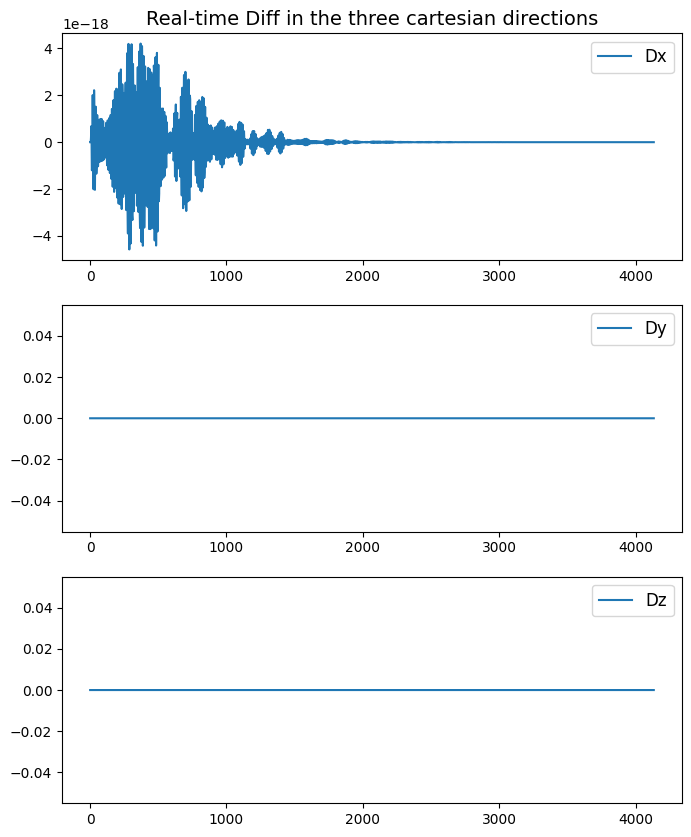

In [11]:
diffe = P_damped-P_damped_yp
Plot_3dArray_time(time_au,diffe,label='Diff')

In [12]:
#e_range = [0,40]
#n_freqs = 200
#freqs=np.linspace(e_range[0],e_range[1],n_freqs)/ha2ev
energy = FT.eval_energy_array(time_au.size,dt=time_au[1]-time_au[0],time_units='au')
Pw = np.fft.rfft(P_damped)

Pw_yp=np.zeros((3,energy.size),dtype=complex)
O.Fourier_Interpolation(P_damped,Pw_yp,time_au,energy,mode="T2W")

Maximum energy value = 1.5190703108508952
Energy sampling step = 0.0015190703108508951


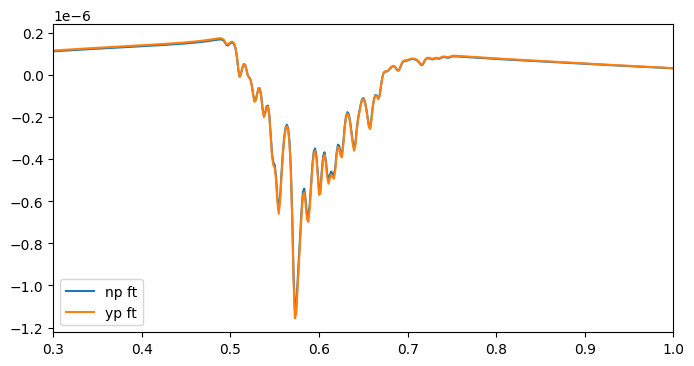

In [13]:
fig, ax1 = plt.subplots(figsize=(8,4))
ax1.plot(energy,-np.imag(2*Pw[0]),label='np ft')
ax1.plot(energy,np.imag(Pw_yp[0]),label='yp ft')
ax1.set_xlim(0.3,1)
ax1.legend()

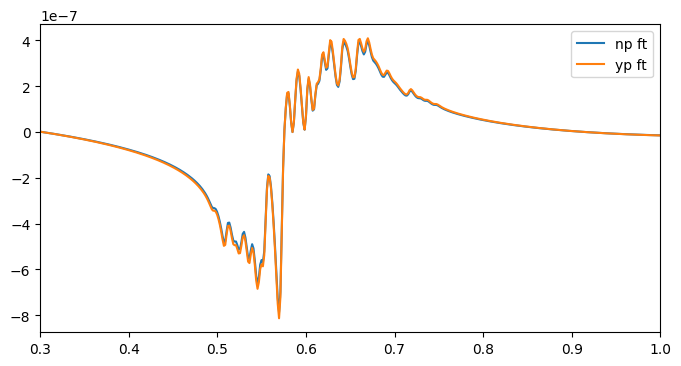

In [14]:
fig, ax1 = plt.subplots(figsize=(8,4))
ax1.plot(energy,np.real(2*Pw[0]),label='np ft')
ax1.plot(energy,np.real(Pw_yp[0]),label='yp ft')
ax1.set_xlim(0.3,1)
ax1.legend()

t_initial = 4.1341373336561364


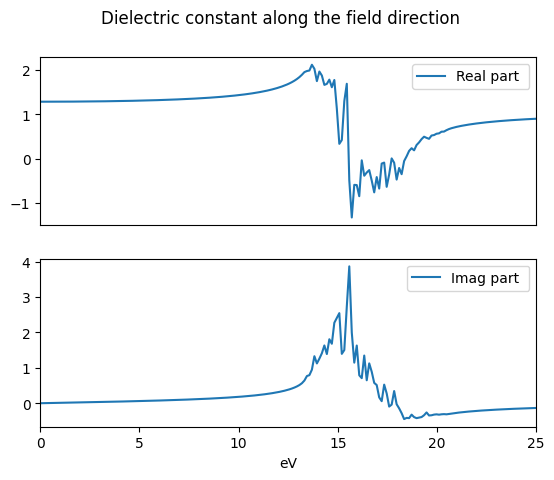

In [107]:
O.YamboPy_Linear_Response(time_au,P_damped,efield,e_range=[0.0, 25.0])